In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps

# Exact OU density

In [4]:
# ============================================================
# 1. OU parameters
# ============================================================

kappa = 1.0
D = 1.0

# Non-stationary Gaussian initial distribution
m0 = -2.0
s0 = 0.5

# Space-time domain
x_L = -5.0
x_R = 5.0
T_final = 3.0

Nx = 400
Nt = 600

x = np.linspace(x_L, x_R, Nx + 1)
t = np.linspace(0.0, T_final, Nt + 1)

dx = x[1] - x[0]
dt = t[1] - t[0]

In [5]:
# ============================================================
# 2. Create the space-time grid
# ============================================================

# X[i, j] = x[i]
# Time[i, j] = t[j]
X, Time = np.meshgrid(x, t, indexing="ij")

In [6]:
# ============================================================
# 3. Exact OU density
# ============================================================

def exact_ou_density(x_grid, t_grid, kappa, D, m0, s0):
    """
    Exact density of

        dX_t = -kappa X_t dt + sqrt(2D) dW_t

    with

        X_0 ~ N(m0, s0^2).
    """

    mean = m0 * np.exp(-kappa * t_grid)

    variance = (
        s0**2 * np.exp(-2.0 * kappa * t_grid)
        + (D / kappa) * (1.0 - np.exp(-2.0 * kappa * t_grid))
    )

    density = (
        np.exp(
            -0.5 * (x_grid - mean)**2 / variance
        )
        / np.sqrt(2.0 * np.pi * variance)
    )

    return density


rho = exact_ou_density(
    X,
    Time,
    kappa,
    D,
    m0,
    s0
)

# PySINDy-compatible PDE shape
rho_data = rho[..., np.newaxis]


print("x shape:       ", x.shape)
print("t shape:       ", t.shape)
print("rho shape:     ", rho.shape)
print("rho_data shape:", rho_data.shape)

x shape:        (401,)
t shape:        (601,)
rho shape:      (401, 601)
rho_data shape: (401, 601, 1)


In [7]:
# ============================================================
# 4. Check mass inside the truncated domain
# ============================================================

mass = np.trapezoid(rho, x=x, axis=0)

print()
print("Minimum mass inside domain:", mass.min())
print("Maximum mass inside domain:", mass.max())


Minimum mass inside domain: 0.9999953839692576
Maximum mass inside domain: 0.9999999990058279


In [8]:
# ============================================================
# 5. Compute derivatives numerically
# ============================================================


# differential operator: \partial_t
Dt = ps.FiniteDifference(
    d=1,
    axis=1,
    order=2,
)

# differential operator: \partial_x, \partial_{xx}, \partial_{xxx}
Dx = ps.FiniteDifference(
    d=1,
    axis=0,
    order=2
)

Dxx = ps.FiniteDifference(
    d=2,
    axis=0,
    order=2
)

Dxxx = ps.FiniteDifference(
    d=3,
    axis=0,
    order=2
)

# Left-hand side: rho_t
rho_t = Dt(rho,t)

# Spatial derivatives
rho_x =Dx(rho,x)

rho_xx =Dxx(rho,x)

rho_xxx = Dxxx(rho,x)

# Conservative drift candidates
d_x_xrho = Dx(X*rho,x)

d_x_x2rho = Dx(X**2*rho,x)

In [9]:
# ============================================================
# 6. Collect the precomputed candidate fields
# ============================================================

candidate_fields = {
    "rho": rho,
    "rho_x": rho_x,
    "d_x(x rho)": d_x_xrho,
    "d_x(x^2 rho)": d_x_x2rho,
    "rho_xx": rho_xx,
    "rho_xxx": rho_xxx,
}

feature_names = list(candidate_fields.keys())

In [10]:
# ============================================================
# 7. Select the interior space-time region
# ============================================================

# Numerical derivatives are usually less accurate near the boundaries.
# We also remove a few initial/final time slices.

space_slice = slice(2, -2)
time_slice = slice(1, -1)

Theta = np.column_stack([
    field[space_slice, time_slice].ravel()
    for field in candidate_fields.values()
])

rho_t_vector = rho_t[
    space_slice,
    time_slice
].ravel().reshape(-1, 1)


print()
print("Theta shape:", Theta.shape)
print("rho_t shape:", rho_t_vector.shape)


Theta shape: (237803, 6)
rho_t shape: (237803, 1)


In [11]:
# ============================================================
# 8. Sparse regression using PySINDy
# ============================================================

optimizer = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True
)

optimizer.fit(
    Theta,
    rho_t_vector
)

coefficients = optimizer.coef_.reshape(-1)

In [12]:
# ============================================================
# 9. Display identified coefficients
# ============================================================

true_coefficients = np.array([
    0.0,       # rho
    0.0,       # rho_x
    kappa,     # d_x(x rho)
    0.0,       # d_x(x^2 rho)
    D,         # rho_xx
    0.0,       # rho_xxx
])

coefficient_table = pd.DataFrame({
    "Candidate term": feature_names,
    "Identified coefficient": coefficients,
    "True coefficient": true_coefficients,
    "Absolute error": np.abs(
        coefficients - true_coefficients
    ),
})

print()
print("Identified coefficient table:")
display(
    coefficient_table.style
    .format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    })
)


Identified coefficient table:


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.000000,0.000000,0.000e+00
1,rho_x,0.000000,0.000000,0.000e+00
2,d_x(x rho),1.000486,1.000000,4.861e-04
3,d_x(x^2 rho),0.000000,0.000000,0.000e+00
4,rho_xx,1.000271,1.000000,2.715e-04
5,rho_xxx,0.000000,0.000000,0.000e+00


In [13]:
# ============================================================
# 10. Print the identified PDE
# ============================================================

identified_terms = []

for name, coefficient in zip(
    feature_names,
    coefficients
):
    if abs(coefficient) > 1e-10:
        identified_terms.append(
            f"({coefficient:+.6f}) {name}"
        )

identified_equation = " ".join(identified_terms)

print()
print("True Fokker-Planck equation:")
print(
    f"rho_t = {kappa:.6f} d_x(x rho)"
    f" + {D:.6f} rho_xx"
)

print()
print("Identified Fokker-Planck equation:")
print(f"rho_t = {identified_equation}")


True Fokker-Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker-Planck equation:
rho_t = (+1.000486) d_x(x rho) (+1.000271) rho_xx


In [14]:
# ============================================================
# 11. Compute predicted rho_t
# ============================================================

rho_t_prediction = np.zeros_like(rho_t)

for coefficient, field in zip(
    coefficients,
    candidate_fields.values()
):
    rho_t_prediction += coefficient * field


rho_t_true_vector = rho_t[
    space_slice,
    time_slice
].ravel()

rho_t_pred_vector = rho_t_prediction[
    space_slice,
    time_slice
].ravel()

relative_l2_error = (
    np.linalg.norm(
        rho_t_true_vector - rho_t_pred_vector
    )
    / np.linalg.norm(rho_t_true_vector)
)

residual_sum_squares = np.sum(
    (rho_t_true_vector - rho_t_pred_vector)**2
)

total_sum_squares = np.sum(
    (
        rho_t_true_vector
        - np.mean(rho_t_true_vector)
    )**2
)

r_squared = 1.0 - (
    residual_sum_squares / total_sum_squares
)

print()
print(
    f"Relative L2 error in rho_t: "
    f"{relative_l2_error:.6e}"
)

print(
    f"R-squared score: "
    f"{r_squared:.10f}"
)


Relative L2 error in rho_t: 5.874945e-04
R-squared score: 0.9999996549


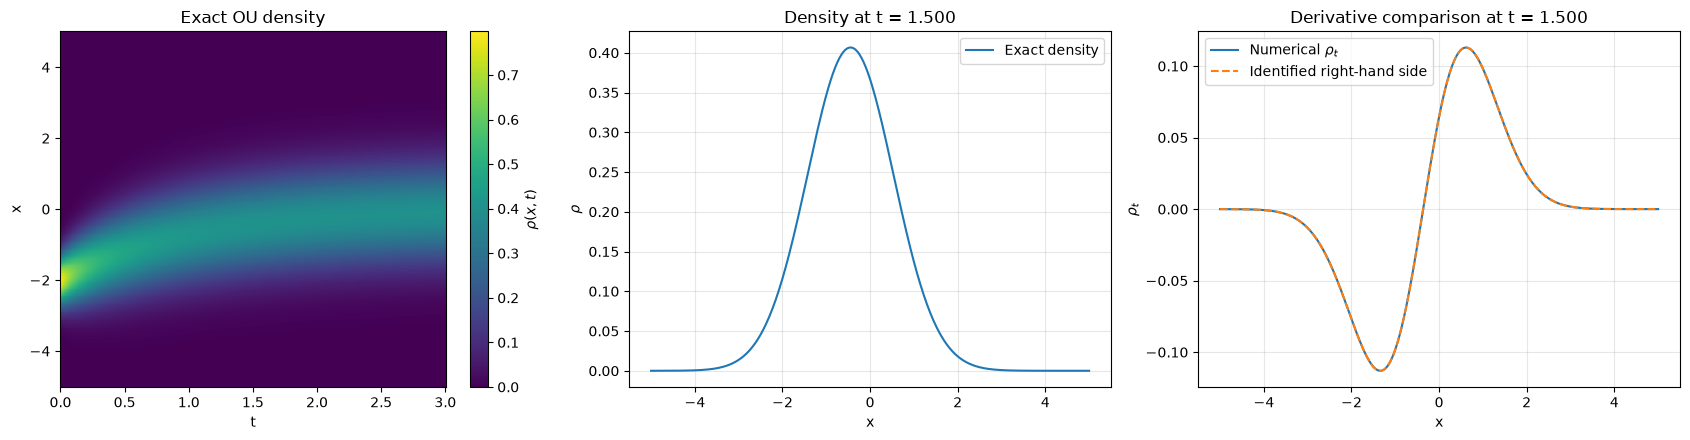

In [15]:
# ============================================================
# 12. Plot exact density and derivative prediction
# ============================================================

mid_time_index = len(t) // 2

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5)
)

# Exact density
density_plot = axes[0].pcolormesh(
    t,
    x,
    rho,
    shading="auto"
)

axes[0].set_xlabel("t")
axes[0].set_ylabel("x")
axes[0].set_title("Exact OU density")

fig.colorbar(
    density_plot,
    ax=axes[0],
    label=r"$\rho(x,t)$"
)

# Density at one time
axes[1].plot(
    x,
    rho[:, mid_time_index],
    label="Exact density"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title(
    f"Density at t = "
    f"{t[mid_time_index]:.3f}"
)

axes[1].grid(alpha=0.3)
axes[1].legend()

# True and identified time derivative
axes[2].plot(
    x,
    rho_t[:, mid_time_index],
    label=r"Numerical $\rho_t$"
)

axes[2].plot(
    x,
    rho_t_prediction[:, mid_time_index],
    linestyle="--",
    label=r"Identified right-hand side"
)

axes[2].set_xlabel("x")
axes[2].set_ylabel(r"$\rho_t$")
axes[2].set_title(
    f"Derivative comparison at t = "
    f"{t[mid_time_index]:.3f}"
)

axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# FD OU density